# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

## config

In [6]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [12]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data: tap - LD

In [8]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'
tab_name = 'tap_LD'

experiment_class = 'Tap escape - light dark'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
# [0:38] 4-fish, [38:66] 1-fish

,experiment,fish_num,light,rig_mm,vid_px
0,jjm240827_s5,4,0,350,942
1,jjm240827_s6,4,0,350,942
2,jjm240827_s7,4,0,350,942
3,jjm240827_s8,4,0,350,942
4,jjm240827_s16,4,0,350,942
...,...,...,...,...,...
61,jjm250613_s10,1,0,350,957
62,jjm250613_s11,1,0,350,957
63,jjm250613_s12,1,0,350,957
64,jjm250613_s13,1,0,350,957


## group size color scheme

['#93c4de', '#4a97c9', '#1764ab', '#08306b']


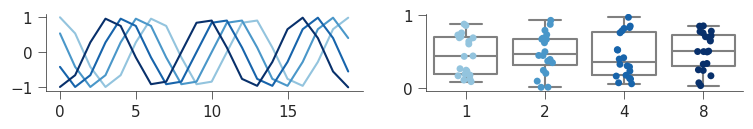

In [9]:
# RGB hex values theme - for summary stats plots
group_names = [1,2,4,8]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.Blues(i/(group_num+1)) for i in range(2,group_num+2)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# S3a - Δ speed time series (1)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3a


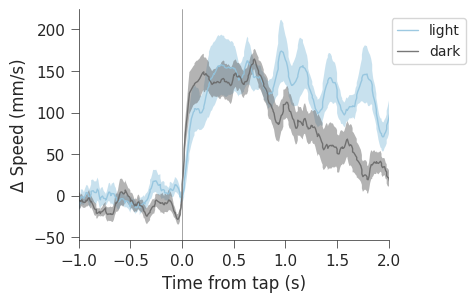

N = [15, 13]


,light_1,light_2,light_3,light_4,light_5,light_6,light_7,light_8,light_9,light_10,...,dark_4,dark_5,dark_6,dark_7,dark_8,dark_9,dark_10,dark_11,dark_12,dark_13
0,-24.812458,-3.878520,71.018435,-13.726008,-11.547584,2.714699,-21.183389,-3.439118,-44.898825,-33.431565,...,-32.124519,38.641160,8.946720,-22.822864,19.626202,-47.627751,29.492506,-23.664178,-29.243364,-12.683679
1,-24.578386,-3.914117,75.006191,-13.726008,-11.561457,2.714699,0.327146,12.339441,-46.172794,-33.433733,...,-29.450252,26.706010,9.169081,-22.047622,19.861263,-48.499598,12.204338,-23.660482,-29.697255,1.471904
2,-24.439151,-4.009341,78.436693,-13.726008,-11.575330,2.714699,0.498755,12.382226,-46.279525,-33.386585,...,-10.268784,27.438242,9.900704,-21.786876,1.502497,-48.824282,13.268622,-23.695628,-30.487210,16.124698
3,-24.607923,-4.222045,82.387895,-13.726008,-11.558883,2.714699,-15.543315,-5.802639,-20.750559,-33.337675,...,10.292666,12.604070,10.759033,-21.846500,-1.385073,-48.440082,31.099260,-23.732325,-30.383435,16.343925
4,-25.704065,-4.227165,86.291893,-10.824760,-11.896926,2.714699,-29.948328,-7.595991,-6.378028,-33.291897,...,14.878779,-1.853006,-6.287945,-21.287365,-16.463562,-48.886691,29.265032,-23.683127,-15.153530,29.985456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,235.285324,82.455387,110.852772,90.681680,110.503032,91.535485,-38.104705,45.241942,25.196263,63.238690,...,-0.050578,-11.520732,77.360079,20.649487,50.267641,16.925404,38.964960,8.095935,5.227942,55.180590
359,235.488966,86.215358,110.689265,72.185665,117.744895,90.692902,-37.801810,52.083395,16.721671,72.196012,...,0.782124,-11.520732,56.441585,20.157799,50.161311,16.293935,35.130266,-5.587243,4.649534,53.542567
360,235.279135,89.975330,110.617224,55.591695,124.986759,82.727048,-37.475400,59.004016,9.554015,81.153334,...,1.896910,-11.520732,49.174231,18.395045,33.160878,16.473672,48.305954,-5.569601,4.718065,51.908259
361,234.655832,93.735301,110.545182,70.238134,132.228622,55.889662,-20.814042,66.003804,3.693296,90.110657,...,3.330878,-11.520732,53.591753,16.146505,15.348074,-6.457704,35.687119,-5.799807,4.714961,66.508576


In [ ]:
subpanel = 'S3a'
light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
hex_colors = ['#93c4de', 'dimgrey']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=1: continue
  if metadata.light[exp]==1: light_cond = 'light'
  if metadata.light[exp]==0: light_cond = 'dark'

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, f_bodylength_mm = data['scale'], data['f_bodylength_mm']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    # subtract baseline (30-sec pre tap) to get change of speed
    group_values[light_cond].append((f_speed[f][tap-int(30*121):tap+int(30*121)])-np.mean(f_speed[f][tap-int(30*121):tap]))

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(light_conditions):
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'{gs}', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5);
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); # plt.ylim(0,15);
plt.xlabel('Time from tap (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[len(group_values[g]) for g in light_conditions]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S3b - Δ speed stats (1)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S3b


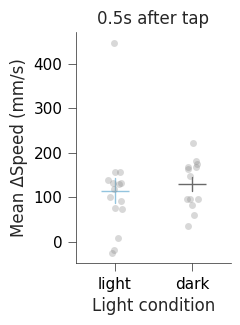

Ns, means, and  sems for data:
light: (N=15) 114.259, 28.308
dark: (N=13) 130.253, 15.419

Normality test (Shapiro-Wilk):
Group light: W = 0.782, p = 2.1633395413e-03
Group dark: W = 0.942, p = 4.7855195379e-01
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 70.000, p = 2.1358632776e-01


,light,dark
0,73.596301,60.289851
1,128.759881,35.658794
2,-18.610464,148.207361
3,101.223592,95.678350
4,156.032022,82.154657
5,447.828079,182.524955
6,8.917934,96.198987
7,-25.059185,96.669327
8,138.976807,173.744812
9,74.736917,162.554237


In [13]:
subpanel = 'S3b'
window_of_interest = [0.5] # sec

rng = np.random.default_rng(seed=39)

for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#93c4de', 'dimgrey']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 1: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [rng.choice(i[:tap], size=window, replace=False) for i in f_speed]
    post_speeds = [i[tap:tap+window] for i in f_speed]

    if fish_num == 1:
      group_values[light_cond].append(np.nanmean(post_speeds[0])-np.nanmean(pre_speeds[0]))
    else:
      group_values[light_cond].append(np.mean([(np.nanmean(post_speeds[f])-np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel(f'Mean ΔSpeed (mm/s)')
  plt.xticks(fontsize=11, color='black'); plt.yticks(fontsize=11, color='black')
  sns.despine(); plt.title(f'{woi}s after tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3c - baseline speed stats (1)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S3c


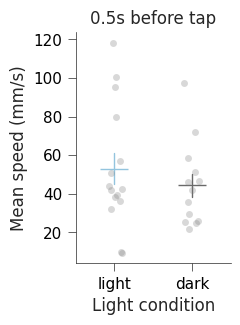

Ns, means, and  sems for data:
light: (N=15) 53.108, 8.229
dark: (N=13) 44.432, 6.058

Normality test (Shapiro-Wilk):
Group light: W = 0.906, p = 1.1648290632e-01
Group dark: W = 0.879, p = 6.9242976366e-02
all groups are normally distributed → use parametric test.

T-test: t = 0.827, p = 4.1594412387e-01


,light,dark
0,42.127054,97.390491
1,42.637700,58.368930
2,118.306917,45.973121
3,10.076071,51.163623
4,9.502631,72.291804
5,100.490401,35.704572
6,95.492587,25.347301
7,79.938064,21.817547
8,50.751267,42.118796
9,44.171049,46.933759


In [14]:
subpanel = 'S3c'
window_of_interest = [0.5] # sec

rng = np.random.default_rng(seed=39)

for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#93c4de', 'dimgrey']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 1: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [rng.choice(i[:tap], size=window, replace=False) for i in f_speed]
    post_speeds = [i[tap:tap+window] for i in f_speed]

    # get mean of the group if n>1
    if fish_num == 1:
      group_values[light_cond].append(np.nanmean(pre_speeds[0]))
    else:
      group_values[light_cond].append(np.mean([(np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel(f'Mean speed (mm/s)')
  plt.xticks(fontsize=11, color='black'); plt.yticks(fontsize=11, color='black')
  sns.despine(); plt.title(f'{woi}s before tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3d - post tap travel dist stats (1)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3d


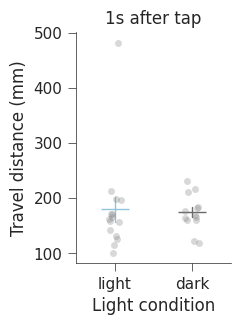

Ns, means, and  sems for data:
light: (N=15) 179.936, 23.057
dark: (N=13) 174.476, 9.110

Normality test (Shapiro-Wilk):
Group light: W = 0.625, p = 0.000
Group dark: W = 0.942, p = 0.482
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 77.000, p = 3.5689023044e-01


,light,dark
0,115.153775,181.725191
1,172.534482,122.077410
2,131.864288,160.915342
3,159.532733,170.120198
4,199.182980,161.637938
5,482.474550,216.927114
6,143.155040,166.887321
7,101.342633,119.576823
8,212.564698,176.530535
9,126.983445,211.402506


In [ ]:
subpanel = 'S3d'
window_of_interest = [1] # sec
for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#93c4de', 'dimgrey']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 1: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[tap:tap+window],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[light_cond].append(f_travel[0])
    else:
      group_values[light_cond].append(np.mean([f_travel[f] for f in range(fish_num)]))


  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1)
  plt.xlabel('Light condition'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s after tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3e - baseline travel dist stats (1)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3e


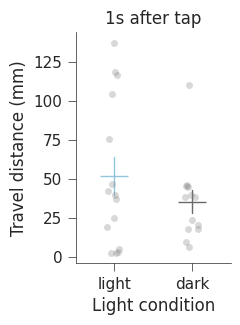

Ns, means, and  sems for data:
light: (N=15) 51.761, 12.108
dark: (N=13) 35.291, 7.325

Normality test (Shapiro-Wilk):
Group light: W = 0.872, p = 0.037
Group dark: W = 0.799, p = 0.007
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 109.000, p = 6.1235214900e-01


,light,dark
0,25.271037,109.800424
1,2.755540,38.286041
2,137.067021,44.970685
3,19.062991,46.373649
4,3.550899,45.589738
5,116.745015,20.195413
6,118.333807,9.607012
7,104.597005,17.750605
8,75.195952,38.723155
9,2.856493,39.456508


In [ ]:
subpanel = 'S3e'
window_of_interest = [1] # sec
for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#93c4de', 'dimgrey']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 1: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[tap-window:tap],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[light_cond].append(f_travel[0])
    else:
      group_values[light_cond].append(np.mean([f_travel[f] for f in range(fish_num)]))


  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s before tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3f - Δ speed time series (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3f


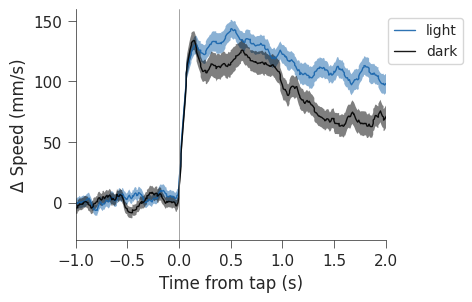

N = [80, 72]


,light_1,light_2,light_3,light_4,light_5,light_6,light_7,light_8,light_9,light_10,...,dark_63,dark_64,dark_65,dark_66,dark_67,dark_68,dark_69,dark_70,dark_71,dark_72
0,12.344064,53.614533,85.731287,-30.606916,70.727412,7.114013,67.670411,-19.005359,-57.738893,-25.137956,...,-41.468307,-21.704431,18.260780,-73.105227,-40.472990,37.329805,-6.548307,64.489154,-3.209696,15.362293
1,11.421415,55.419804,107.953341,-8.755369,81.508628,5.068354,68.566568,-18.384460,-56.675321,-24.727691,...,-41.694760,-21.271550,15.648973,-72.787061,-40.419645,37.872906,-6.239052,54.451860,-2.789339,-0.678489
2,12.384093,54.978343,126.619382,8.499908,98.503307,4.598277,45.017949,-18.091133,-59.002270,-22.478510,...,-41.087292,-22.288830,14.927487,-72.636694,-40.505412,38.236361,-7.085480,60.228839,-20.056815,0.891381
3,13.117434,54.611981,125.812038,28.858364,112.254211,27.737706,39.896902,-18.569666,-60.997764,-24.360843,...,-39.989531,-19.196759,6.732879,-72.180521,-40.632288,21.041559,-23.463544,59.216091,-37.044945,16.982984
4,-4.832943,55.007496,129.352128,44.389301,111.302394,23.885814,58.023074,-19.040427,-61.116319,-26.979958,...,-41.119030,-17.200424,10.573637,-71.598163,-41.020092,23.841486,-41.022087,57.489128,-36.882591,16.404683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,110.087038,9.022964,112.034823,61.845138,125.296020,88.456700,98.882414,-9.107319,85.000727,-4.877284,...,-9.797193,9.726969,38.665036,-17.697959,152.402004,181.909922,8.249203,136.263725,-41.816806,-1.820256
359,110.676935,28.903543,116.198319,53.045695,117.348406,71.017180,123.572025,5.719077,96.526692,-19.345687,...,-11.868574,15.514173,40.805033,-34.788426,144.500345,179.333444,6.503272,128.443256,-41.072306,-1.793428
360,115.649098,24.865605,109.197426,73.379752,114.330494,54.191164,134.865489,20.240499,100.359637,-17.661718,...,-25.589663,29.865676,37.042890,-35.199562,121.711691,176.117107,9.986419,122.811307,-38.732482,-3.441220
361,124.206702,27.628042,89.991059,82.780624,111.779375,51.285642,129.056006,19.403831,101.150438,-12.844705,...,-39.552926,13.592762,35.955193,-37.291953,123.212311,173.737628,3.699096,114.141724,-17.836813,-3.606022


In [ ]:
subpanel = 'S3f'
light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
hex_colors = ['#1764ab', 'black']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue
  if metadata.light[exp]==1: light_cond = 'light'
  if metadata.light[exp]==0: light_cond = 'dark'

  # load data
  if os.path.exists(load_path + 'lev0_basics.npz') == False: continue
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, f_bodylength_mm = data['scale'], data['f_bodylength_mm']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    # subtract baseline (30-sec pre tap) to get change of speed
    group_values[light_cond].append((f_speed[f][tap-int(30*121):tap+int(30*121)])-np.mean(f_speed[f][tap-int(30*121):tap]))

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(light_conditions):
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'{gs}', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5);
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2);
plt.xlabel('Time from tap (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[len(group_values[g]) for g in light_conditions]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S3g - Δ speed stats (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S3g


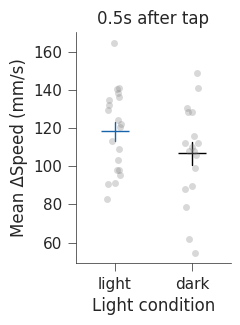

Ns, means, and  sems for data:
light: (N=20) 118.276, 4.861
dark: (N=18) 106.682, 5.942

Normality test (Shapiro-Wilk):
Group light: W = 0.959, p = 0.524
Group dark: W = 0.964, p = 0.676
all groups are normally distributed → use parametric test.

T-test: t = 1.522, p = 1.3666181390e-01


,light,dark
0,120.489320,112.116827
1,95.261223,148.883071
2,138.447497,107.980613
3,103.134378,89.680429
4,91.359440,98.863600
5,140.987826,78.668746
6,136.443457,61.923966
7,124.412262,88.014268
8,134.849579,130.398303
9,97.820979,128.307922


In [15]:
subpanel = 'S3g'
window_of_interest = [0.5] # sec

rng = np.random.default_rng(seed=39)

for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#1764ab', 'black']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 4: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [rng.choice(i[:tap], size=window, replace=False) for i in f_speed]
    post_speeds = [i[tap:tap+window] for i in f_speed]

    # get mean of the group if n>1
    if fish_num == 1:
      group_values[light_cond].append(np.nanmean(post_speeds[0])-np.nanmean(pre_speeds[0]))
    else:
      group_values[light_cond].append(np.mean([(np.nanmean(post_speeds[f])-np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel(f'Mean ΔSpeed (mm/s)')
  sns.despine(); plt.title(f'{woi}s after tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3h - baseline speed stats (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S3h


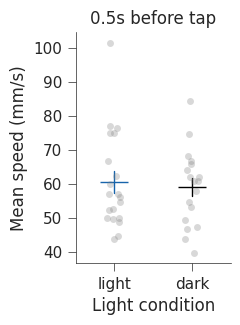

Ns, means, and  sems for data:
light: (N=20) 60.584, 3.186
dark: (N=18) 59.033, 2.663

Normality test (Shapiro-Wilk):
Group light: W = 0.871, p = 0.012
Group dark: W = 0.977, p = 0.908
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 181.000, p = 9.8833723113e-01


,light,dark
0,49.722527,61.920866
1,59.984956,49.417986
2,62.334926,43.803893
3,66.789567,39.811594
4,54.731630,60.846206
5,44.859275,65.916536
6,52.639194,62.012590
7,56.950345,68.261135
8,52.390535,64.011631
9,48.894547,60.882377


In [16]:
subpanel = 'S3h'
window_of_interest = [0.5] # sec

rng = np.random.default_rng(seed=39)

for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#1764ab', 'black']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 4: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [rng.choice(i[:tap], size=window, replace=False) for i in f_speed]
    post_speeds = [i[tap:tap+window] for i in f_speed]

    # get mean of the group if n>1
    if fish_num == 1:
      group_values[light_cond].append(np.nanmean(pre_speeds[0]))
    else:
      group_values[light_cond].append(np.mean([(np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel(f'Mean speed (mm/s)')
  sns.despine(); plt.title(f'{woi}s before tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3i - post tap travel dist stats (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3i


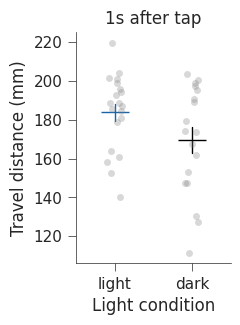

Ns, means, and  sems for data:
light: (N=20) 183.998, 4.422
dark: (N=18) 169.481, 6.627

Normality test (Shapiro-Wilk):
Group light: W = 0.949, p = 3.4497774441e-01
Group dark: W = 0.927, p = 1.7351906113e-01
all groups are normally distributed → use parametric test.

T-test: t = 1.856, p = 7.1674584933e-02


,light,dark
0,152.622076,179.358679
1,163.911117,199.200295
2,198.843079,167.572668
3,158.260642,130.628340
4,140.340716,147.360621
5,184.834918,147.454158
6,194.549232,127.106929
7,188.921219,153.085637
8,196.039972,197.238338
9,160.887308,190.851791


In [ ]:
subpanel = 'S3i'
window_of_interest = [1]

for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#1764ab', 'black']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 4: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[tap:tap+window],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[light_cond].append(f_travel[0])
    else:
      group_values[light_cond].append(np.mean([f_travel[f] for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s after tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3j - baseline travel dist stats (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3j


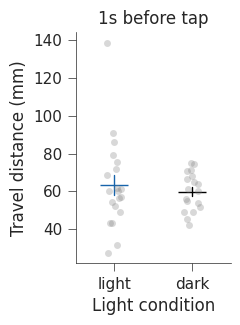

Ns, means, and  sems for data:
light: (N=20) 63.466, 5.402
dark: (N=18) 59.874, 2.384

Normality test (Shapiro-Wilk):
Group light: W = 0.889, p = 2.6194239125e-02
Group dark: W = 0.958, p = 5.5640887926e-01
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 188.000, p = 8.2644401017e-01


,light,dark
0,60.191413,55.786973
1,86.290574,48.844872
2,61.310143,42.428974
3,71.634590,64.822486
4,48.964370,74.892301
5,60.370883,54.770671
6,43.426636,60.421688
7,27.475290,74.422018
8,68.627106,70.746172
9,43.244085,60.992268


In [ ]:
subpanel = 'S3j'
window_of_interest = [1]

for woi in window_of_interest:

  light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
  hex_colors = ['#1764ab', 'black']

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num != 4: continue
    if metadata.light[exp]==1: light_cond = 'light'
    if metadata.light[exp]==0: light_cond = 'dark'

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi); dt = 1/fps
    f_travel = [np.trapezoid(sp[tap-window:tap],dx=dt) for sp in f_speed]

    # take mean of the group if >1 fish
    if fish_num == 1:
      group_values[light_cond].append(f_travel[0])
    else:
      group_values[light_cond].append(np.mean([f_travel[f] for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Light condition'); plt.ylabel('Travel distance (mm)')
  sns.despine(); plt.title(f'{woi}s before tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  light_conditions = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups);
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[key] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3k - iid% time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3k


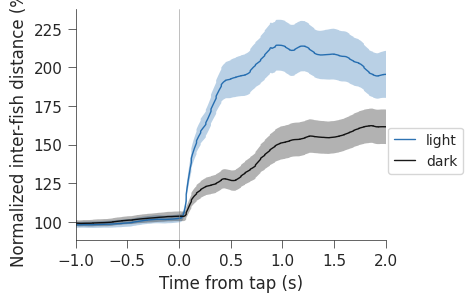

N = [20, 18]


,light_1,light_2,light_3,light_4,light_5,light_6,light_7,light_8,light_9,light_10,...,dark_99,dark_100,dark_101,dark_102,dark_103,dark_104,dark_105,dark_106,dark_107,dark_108
0,67.737096,73.650098,100.351099,67.570552,104.787234,107.903469,71.318126,88.337582,100.212904,76.781986,...,93.250095,124.171916,118.820147,82.467604,90.081800,96.074773,93.908704,95.641215,86.581764,73.671794
1,67.416089,72.911917,100.332281,67.017407,104.831181,108.184050,70.395110,87.126859,100.235236,76.498646,...,93.346889,124.158305,118.828353,82.269630,89.597672,95.848714,93.737185,95.443183,86.367545,73.562373
2,67.163002,72.346604,100.283781,66.652561,104.879002,108.395457,69.833408,86.221743,100.275283,76.531842,...,93.748690,124.134452,119.080893,82.201420,89.483299,95.619237,93.558858,94.833172,85.867480,73.123937
3,66.872765,71.808001,100.275184,65.732546,104.916446,108.647858,69.449692,86.004256,100.207008,76.485500,...,94.161146,124.115716,119.343360,82.129000,89.293276,95.379561,93.367933,94.174921,85.307043,72.684360
4,66.648449,71.262981,100.219579,65.483257,104.966952,108.851760,68.786605,86.021926,100.068534,76.402089,...,94.366620,124.102880,119.357409,81.939542,89.400850,95.333029,93.348276,93.505823,84.766705,72.310161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,65.360152,111.485408,93.614571,174.378724,89.042217,75.700878,42.913965,98.248876,110.236003,84.521130,...,169.402013,124.507466,195.206502,212.370517,150.650415,15.813944,137.147159,167.479762,118.455719,343.960950
359,65.070556,111.447803,93.387739,175.432026,88.918561,75.394287,42.137080,96.454891,109.920158,83.915760,...,167.338442,124.566457,193.617753,211.970853,150.399007,15.779476,137.381727,167.123431,118.958871,344.451406
360,64.267139,111.063774,93.079004,177.226822,88.992052,75.197395,40.926357,95.155773,109.508331,83.492747,...,165.976866,124.602828,192.495564,211.814980,149.848472,15.575513,137.626974,166.576287,119.554186,344.872814
361,63.743353,110.809879,92.964904,178.414696,89.147763,75.114489,40.219223,93.452725,109.204603,83.023883,...,164.709607,124.413490,191.455647,211.492884,148.883513,15.368937,137.879888,165.528857,120.341128,345.294403


In [ ]:
subpanel = 'S3k'

light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
hex_colors = ['#1764ab', 'black']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue
  if metadata.light[exp]==1: light_cond = 'light'
  if metadata.light[exp]==0: light_cond = 'dark'

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_px = data['f_bodylength_px']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID']
  f_IID_bd = f_IID/np.mean(f_bodylength_px)

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # closest distance - real data
  baseline = [np.mean(dist[tap-int(5*fps):tap]) for dist in f_IID_bd]
  tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

  # append real data
  pair_num = f_IID.shape[0]
  for f in range(pair_num):
    group_values[light_cond].append(tmp[f][tap-int(30*121):tap+int(30*121)]*100)

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(light_conditions):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label=f"{gs}")
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); # plt.ylim(0.75,1.9);
plt.xlabel('Time from tap (s)')
plt.ylabel('Normalized inter-fish distance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in light_conditions]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S3l - iid% stats

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3l


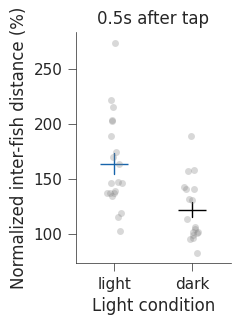

Ns, means, and  sems for data:
light: (N=20) 163.960, 9.558
dark: (N=18) 122.011, 6.725

Normality test (Shapiro-Wilk):
Group light: W = 0.925, p = 0.122
Group dark: W = 0.912, p = 0.094
all groups are normally distributed → use parametric test.

T-test: t = 3.516, p = 1.2048171088e-03


,light,dark
0,137.183524,130.827558
1,202.934163,101.796938
2,115.877190,131.817499
3,134.532882,143.157480
4,146.441917,140.941485
5,137.181881,101.962929
6,146.963003,95.968030
7,204.112447,98.618401
8,163.466802,113.720557
9,103.110899,82.897753


In [ ]:
subpanel = 'S3l'
escp_window = 0.5

light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
hex_colors = ['#1764ab', 'black']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num != 4: continue
  if metadata.light[exp]==1: light_cond = 'light'
  if metadata.light[exp]==0: light_cond = 'dark'

  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_px = data['f_bodylength_px']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID']
  f_IID_bd = f_IID/np.mean(f_bodylength_px)

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # closest distance - real data
  baseline = [np.mean(dist[tap-int(1*fps):tap]) for dist in f_IID_bd]
  tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

  # get change btw pre and post tap
  window = int(fps*escp_window); dt = 1/fps;
  delta = [np.mean(t[tap:tap+window]) for t in tmp] # mean

  group_values[light_cond].append(np.mean(delta)*100)

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.xlabel('Light condition'); plt.ylabel('Normalized inter-fish distance (%)'); plt.title(f'{escp_window}s after tap')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# stats
light_conditions = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{light_conditions[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[key] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S3m - iid (bd) time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3m


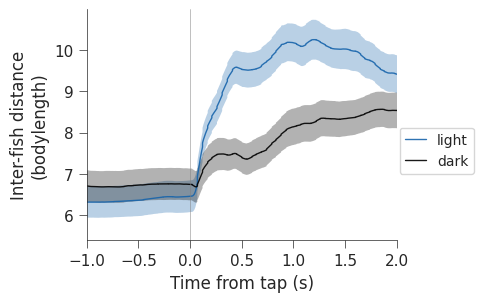

N = [20, 18]


,light_1,light_2,light_3,light_4,light_5,light_6,light_7,light_8,light_9,light_10,...,dark_99,dark_100,dark_101,dark_102,dark_103,dark_104,dark_105,dark_106,dark_107,dark_108
0,5.410157,5.709271,18.088766,1.327590,14.331295,13.203253,2.611928,1.939930,9.272334,3.093586,...,5.725793,5.979657,6.981372,5.080585,3.943673,6.922663,7.600459,3.794447,5.590114,2.540862
1,5.384519,5.652048,18.085374,1.316722,14.337306,13.237585,2.578123,1.913342,9.274400,3.082170,...,5.731736,5.979002,6.981855,5.068388,3.922478,6.906375,7.586578,3.786591,5.576283,2.537088
2,5.364305,5.608226,18.076632,1.309554,14.343846,13.263453,2.557552,1.893465,9.278106,3.083507,...,5.756408,5.977853,6.996693,5.064186,3.917471,6.889840,7.572145,3.762389,5.543996,2.521967
3,5.341123,5.566474,18.075082,1.291478,14.348967,13.294337,2.543499,1.888689,9.271788,3.081640,...,5.781733,5.976951,7.012114,5.059724,3.909152,6.872570,7.556692,3.736274,5.507812,2.506807
4,5.323207,5.524225,18.065059,1.286580,14.355874,13.319287,2.519214,1.889077,9.258976,3.078280,...,5.794350,5.976333,7.012940,5.048052,3.913862,6.869217,7.555101,3.709728,5.472925,2.493901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,5.220311,8.642221,16.874475,3.426101,12.177917,9.262889,1.571665,2.157586,10.199735,3.405400,...,10.401714,5.995816,11.469514,13.083518,6.595294,1.139473,11.099945,6.644553,7.648042,11.862848
359,5.197181,8.639306,16.833587,3.446795,12.161006,9.225374,1.543212,2.118190,10.170511,3.381009,...,10.275005,5.998657,11.376165,13.058896,6.584288,1.136989,11.118929,6.630416,7.680528,11.879764
360,5.133012,8.609537,16.777936,3.482058,12.171057,9.201282,1.498871,2.089660,10.132406,3.363966,...,10.191401,6.000408,11.310230,13.049293,6.560186,1.122293,11.138778,6.608709,7.718964,11.894298
361,5.091177,8.589855,16.757369,3.505397,12.192353,9.191137,1.472973,2.052261,10.104303,3.345075,...,10.113588,5.991291,11.249129,13.029450,6.517941,1.107408,11.159248,6.567153,7.769772,11.908838


In [ ]:
subpanel = 'S3m'

light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
hex_colors = ['#1764ab', 'black']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue
  if metadata.light[exp]==1: light_cond = 'light'
  if metadata.light[exp]==0: light_cond = 'dark'

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID'] # in mm
  f_IID_bd = f_IID/np.mean(f_bodylength_mm)

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # append real data
  pair_num = f_IID.shape[0]
  for f in range(pair_num):
    group_values[light_cond].append(f_IID_bd[f][tap-int(30*121):tap+int(30*121)])

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(light_conditions):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label=f"{gs}")
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2);
plt.xlabel('Time from tap (s)'); plt.ylabel('Inter-fish distance\n(bodylength)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in light_conditions]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S3n - iid% long time series

/tmp/ipykernel_3986/2154538902.py:49: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  baseline_sem = scipy.stats.sem(np.mean(tmp))


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S3n


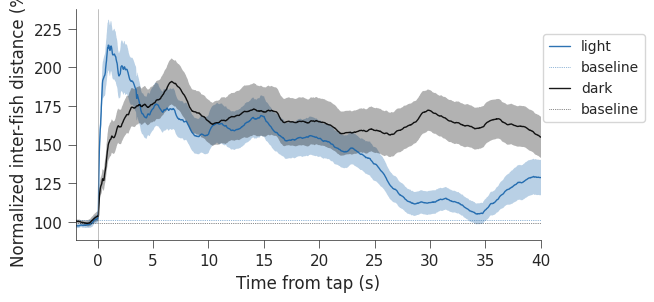

N = [20, 18]


,light_1,light_2,light_3,light_4,light_5,light_6,light_7,light_8,light_9,light_10,...,dark_99,dark_100,dark_101,dark_102,dark_103,dark_104,dark_105,dark_106,dark_107,dark_108
0,121.779842,101.806343,99.732696,175.593017,99.067297,95.555826,125.991727,93.133929,110.429245,118.253799,...,93.576226,107.434806,99.441069,88.313996,126.688375,128.863552,120.732043,109.008136,98.542606,98.260070
1,121.596017,101.774365,99.727768,175.494068,99.156568,95.570444,125.675880,93.373660,110.242055,118.161039,...,93.354385,107.685171,99.393599,88.290134,126.120472,128.587898,120.532853,109.145239,98.579051,98.120917
2,121.419384,101.738124,99.714375,175.463541,99.246338,95.577180,125.722242,93.489869,110.183091,118.086450,...,93.366522,107.931415,99.617323,88.363180,125.557410,128.256245,120.045220,109.429378,98.460611,97.543091
3,121.211608,101.727750,99.709279,175.356662,99.362889,95.589154,125.787989,94.319624,110.127461,118.057851,...,93.390405,107.957558,99.890553,88.421763,125.247030,127.906364,119.546191,109.454360,98.278924,97.035573
4,121.025450,101.542868,99.751450,175.492385,99.569639,95.776765,125.757110,95.137517,110.083537,118.050158,...,93.362436,107.986123,100.156498,88.493748,124.873757,127.616034,119.172026,109.856192,98.539354,96.957679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5077,15.575151,34.277723,73.358599,102.063122,96.084106,91.781780,73.865963,776.795001,127.584811,381.644693,...,87.451894,93.495543,135.488356,57.912530,85.584102,71.177871,24.387541,34.926291,29.755871,95.437699
5078,15.493494,34.257723,73.339905,103.315953,96.255165,91.782220,73.364940,778.531853,127.380765,382.727245,...,87.715134,93.316999,135.315573,57.933328,85.440850,71.121761,24.356139,34.982000,29.638367,95.294390
5079,15.512098,34.230865,73.332855,105.218613,96.550746,91.791771,72.888846,779.359189,127.175657,383.301224,...,88.016362,93.132391,135.127526,57.946538,85.438586,70.853291,24.429559,34.519453,29.572950,94.677539
5080,15.500212,34.251185,73.330861,107.883620,96.929787,91.784104,72.076182,780.464500,126.971231,384.014650,...,88.250831,92.665736,134.668542,57.947468,85.300146,70.587825,24.509099,34.187602,29.468149,94.071504


In [ ]:
subpanel = 'S3n'

light_conditions = ['light','dark']; group_values = {n: [] for n in light_conditions}
hex_colors = ['#1764ab', 'black']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue
  if metadata.light[exp]==1: light_cond = 'light'
  if metadata.light[exp]==0: light_cond = 'dark'

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID']
  f_IID_bd = f_IID/np.mean(f_bodylength_mm)

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # closest distance - real data
  baseline = [np.mean(dist[tap-int(5*fps):tap]) for dist in f_IID_bd]
  tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

  # append real data
  pair_num = f_IID.shape[0]
  for f in range(pair_num):
    group_values[light_cond].append(tmp[f][tap-int(30*121):tap+int(55*121)]*100)

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,55,55*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[6,3])
for i, gs in enumerate(light_conditions):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label=f"{gs}")
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot baseline (5-sec pre tap)
  tmp = np.array([t[24*121:29*121] for t in group_values[gs]]) # take 5s before tap
  baseline_mean = np.mean(np.mean(tmp))
  baseline_sem = scipy.stats.sem(np.mean(tmp))
  plt.axhline(baseline_mean,c=hex_colors[i],linestyle=':',linewidth=0.5, alpha=0.9, label='baseline')
  plt.axhspan(baseline_mean-baseline_sem,baseline_mean+baseline_sem,\
              color='grey',alpha=0.2)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-2,40); # plt.ylim(0.75,1.9);
plt.xlabel('Time from tap (s)'); plt.ylabel('Normalized inter-fish distance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in light_conditions]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -2, 40; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)